<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">

<div style="color: #4a148c; font-size: 2em; font-weight: 800; margin-bottom: 10px; letter-spacing: 0.5px;">
کتاب درک شهودی یادگیری ماشین
</div>

<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 15px auto;">

<h2 style="color: #4a148c; margin: 0; font-size: 1.6em; font-weight: bold;">
فصل پنجم: پیش‌پردازش داده‌ها
</h2>

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۱ شناخت ساختار فایل
کد زیر فایل را می‌خواند و چند سطر اول را نشان می‌دهد. `dtype="string"` باعث می‌شود صفر ابتدای کدهایی مانند `IUCR` از بین نرود. در این مرحله تبدیل نوع هر ستون را آگاهانه و جداگانه انجام می‌دهیم.

</div>


In [1]:
import pandas as pd

from pathlib import Path
file_path = Path("Crime_data from 2001 to present.csv")
if not file_path.exists():
    file_path = Path("..") / file_path
raw = pd.read_csv(file_path, dtype="string", keep_default_na=False)
df = raw.copy()

print("Rows:", len(df), "Columns:", df.shape[1])
display(df[["ID", "Date", "Primary Type", "IUCR"]].head(3))

Rows: 680379 Columns: 22


,ID,Date,Primary Type,IUCR
0,12045583,5/7/2020 10:24,THEFT,0820
1,12031001,4/16/2020 5:00,BATTERY,0460
2,12093529,7/1/2020 10:16,ASSAULT,051A


<div dir="rtl" align="right">

هر ردیف یک رکورد ثبت‌شده است. `ID` شناسهٔ رکورد، `Date` زمان رخداد، `Primary Type` نوع جرم و `IUCR` کد طبقه‌بندی آن است. شناسه یا کد را نباید صرفاً به دلیل ظاهر عددی، یک کمیت قابل میانگین‌گیری بدانیم.

اکنون خانه‌های خالی، ردیف‌های یکسان و شناسه‌های تکراری را می‌شماریم. رشته‌های خالی یا شامل فاصله نیز در بررسی گمشدگی حساب می‌شوند.

</div>


In [2]:
missing = df.replace(r"^\s*$", pd.NA, regex=True).isna()
quality = pd.Series({
    "Missing cells": int(missing.sum().sum()),
    "Duplicate rows": int(df.duplicated().sum()),
    "Duplicate IDs": int(df["ID"].duplicated().sum())
}, name="Count")
display(quality.to_frame())

,Count
Missing cells,0
Duplicate rows,0
Duplicate IDs,0


<div dir="rtl" align="right">

در نسخه بررسی‌شده، فایل ۶۸۰٬۳۷۹ ردیف و ۲۲ ستون دارد و هر سه شمارش بالا صفر است. این نتیجه فقط درباره نسخه ارسالی است؛ نبود خانه خالی، کامل یا بی‌خطا بودن داده را تضمین نمی‌کند. چون گمشدگی واقعی پیدا نشده، آموزش جایگذاری در بخش بعد روی یک کپی آموزشی با گمشدگی مصنوعی و اعلام‌شده انجام می‌شود.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۲ اصلاحات اولیه
ستون تاریخ در ابتدا متن است. آن را به قالب ماه/روز/سال تبدیل می‌کنیم. `errors="coerce"` مقدار نامعتبر را به `NaT` تبدیل می‌کند؛ شمارش آن مانع پنهان ماندن خطای تبدیل می‌شود.

</div>


In [3]:
df["Date"] = pd.to_datetime(
    df["Date"], format="%m/%d/%Y %H:%M", errors="coerce"
)
print("Invalid dates:", int(df["Date"].isna().sum()))
print("First date:", df["Date"].min().strftime("%Y-%m-%d"))
print("Last date:", df["Date"].max().strftime("%Y-%m-%d"))

Invalid dates: 0
First date: 2001-01-01
Last date: 2024-07-15


<div dir="rtl" align="right">

همه تاریخ‌ها قابل تبدیل‌اند و بازهٔ فایل از ۲۰۰۱/۰۱/۰۱ تا ۲۰۲۴/۰۷/۱۵ است. با این حال، تعداد رکوردها در سال‌های مختلف بسیار نامتوازن است؛ پس از روی این بازه به‌تنهایی نمی‌توان کامل بودن تاریخچه یا روند واقعی جرم را نتیجه گرفت.

در ستون نوع جرم، دو صورت نوشتاری `CRIM SEXUAL ASSAULT` و `CRIMINAL SEXUAL ASSAULT` دیده می‌شود. در بررسی کدهای IUCR مشترک، این دو صورت برای یک طبقه به کار رفته‌اند. در کپی کاری، صورت کوتاه را یکسان می‌کنیم؛ سایر عنوان‌ها دست‌نخورده می‌مانند.

</div>


In [4]:
before = df["Primary Type"].nunique()
df["Primary Type"] = df["Primary Type"].replace({
    "CRIM SEXUAL ASSAULT": "CRIMINAL SEXUAL ASSAULT"
})
print("Crime labels:", before, "->", df["Primary Type"].nunique())
print("Rows after preparation:", len(df))

Crime labels: 33 -> 32
Rows after preparation: 680379


<div dir="rtl" align="right">

تعداد عنوان‌ها از ۳۳ به ۳۲ می‌رسد و تعداد ردیف‌ها تغییر نمی‌کند. این کار، اصلاح یکسان‌نویسی است؛ حذف کلاس نادر یا متوازن‌سازی داده نیست.

**چرا شماره پرونده را معیار حذف نگذاشتیم؟** شماره پرونده در بعضی رکوردهای قتل تکرار می‌شود و یک پرونده می‌تواند چند رکورد مربوط به قربانیان داشته باشد. در این مرحله هیچ ردیفی حذف نمی‌شود. بررسی مختصات نامعتبر به بخش نویز و داده‌های پرت مربوط است.

**حاصل این مرحله:** `raw` نسخه اولیه در حافظه و `df` نسخه کاری با تاریخ قابل پردازش و عنوان‌های یکدست است. در مثال بعد، مسئله آموزشی را تعریف و داده را تقسیم می‌کنیم.

**منبع:** فایل CSV ارسالی کاربر؛ مرجع شرح رکوردها: https://catalog.data.gov/dataset/crimes-2001-to-present . اعداد بالا مربوط به همین فایل هستند، نه آخرین نسخه پایگاه آنلاین.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۳ تعریف مسئله و تقسیم زمانی

در این تمرین، هر ردیف یک جرم ثبت‌شده را توصیف می‌کند. مدل با استفاده از زمان و اطلاعات مکانیِ همان ردیف، تشخیص می‌دهد نوع جرم «سرقت» (THEFT) است یا یکی از سایر انواع جرم. پس پرسش مدل این است: «این گزارش مربوط به سرقت است؟» برای پیش‌بینی اینکه در یک زمان و مکان جرمی رخ خواهد داد یا نه، این داده کافی نیست؛ چون نمونه‌ای از زمان‌ها و مکان‌های بدون وقوع جرم در آن نداریم.

برای داشتن یک بازهٔ مشخص، رکوردهای سال ۲۰۲۱ را انتخاب می‌کنیم. مدل با داده‌های ژانویه تا سپتامبر آموزش می‌بیند و با داده‌های اکتبر تا دسامبر آزموده می‌شود؛ یعنی آموزش از نظر زمانی پیش از آزمون قرار دارد. مقدار هدف برای THEFT برابر ۱ و برای سایر انواع جرم صفر است.

ستون‌های IUCR، Description و FBI Code خودِ نوع جرم را آشکار می‌کنند و ورودی مدل نیستند. شناسه‌ها، نتیجهٔ بازداشت و زمان به‌روزرسانی نیز کنار گذاشته می‌شوند.

</div>


In [5]:
df["Date"] = pd.to_datetime(
    df["Date"], format="%m/%d/%Y %H:%M", errors="coerce"
)
print("Invalid dates excluded:", int(df["Date"].isna().sum()))
work = df.loc[df["Date"].dt.year.eq(2021)].copy()
work = work.sort_values(["Date", "ID"])
train = work.loc[work["Date"] < "2021-10-01"].copy()
test = work.loc[work["Date"] >= "2021-10-01"].copy()
y_train = train["Primary Type"].eq("THEFT").astype(int)
y_test = test["Primary Type"].eq("THEFT").astype(int)
print("Train:", len(train), "Test:", len(test))
print("Time separated:", train["Date"].max() < test["Date"].min())
print("Shared cases:", len(set(train["Case Number"]) &
                           set(test["Case Number"])))

Invalid dates excluded: 0
Train: 149811 Test: 51410
Time separated: True
Shared cases: 0


<div dir="rtl" align="right">

۱۴۹٬۸۱۱ رکورد آموزش و ۵۱٬۴۱۰ رکورد آزمون داریم؛ هیچ شماره پروندهٔ مشترکی میان آن‌ها نیست. آزمون برای تنظیم ویژگی‌ها، تعداد مؤلفه‌ها یا آستانهٔ تصمیم استفاده نمی‌شود. برای تنظیم مدل روی دادهٔ زمانی، اعتبارسنجی نیز باید ترتیب زمان را حفظ کند.

</div>


In [6]:
from sklearn.model_selection import TimeSeriesSplit

train_days = pd.Index(train["Date"].dt.normalize().unique()).sort_values()
folds = []
for fold, (a, b) in enumerate(TimeSeriesSplit(n_splits=3).split(train_days), 1):
    folds.append({"Fold": fold, "Train days": len(a), "Valid days": len(b),
                  "Last train": train_days[a[-1]].date(),
                  "First valid": train_days[b[0]].date()})
display(pd.DataFrame(folds))

,Fold,Train days,Valid days,Last train,First valid
0,1,69,68,2021-03-10,2021-03-11
1,2,137,68,2021-05-17,2021-05-18
2,3,205,68,2021-07-24,2021-07-25


<div dir="rtl" align="right">

این جدول تنها مرز سه دور اعتبارسنجی را نشان می‌دهد و مدل را تنظیم نمی‌کند. تقسیم‌بندی بر اساس روز انجام شده است تا هیچ روزی بین مجموعهٔ آموزش و اعتبارسنجی پخش نشود. در هر دور، کل زنجیرهٔ پیش‌پردازش باید دوباره تنها روی داده‌های آموزشِ همان دور fit شود. روش‌های Hold-Out تصادفی و Stratified K-Fold برای فرض مشاهدات مستقل طراحی شده‌اند؛ لذا در مسئلهٔ زمانی حاضر، انتخاب‌های اولیه‌ای نیستند.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۴ گمشدگی و جایگذاری
فایل اصلی خانهٔ خالی ندارد. تنها در یک کپی آموزشی از ستون «نوع محل»، ۱۰ مقدار در آموزش و ۵ مقدار در آزمون را با بذر (Seed) ثابت، خالی (NaN) می‌کنیم. «مُد» از داده‌های آموزش آموخته می‌شود و همان مقدار بر داده‌های آزمون اعمال می‌گردد. هدف این کار، صرفاً نمایش روش است؛ لذا این گمشدگیِ ساختگی را با نقص‌های واقعی فایل اشتباه نگیرید.

</div>


In [7]:
import numpy as np
from sklearn.impute import SimpleImputer

cat_train = train[["Location Description"]].astype(object).copy()
cat_test = test[["Location Description"]].astype(object).copy()
cat_train.loc[cat_train.sample(10, random_state=42).index, :] = np.nan
cat_test.loc[cat_test.sample(5, random_state=42).index, :] = np.nan
imputer = SimpleImputer(strategy="most_frequent")
filled_train = imputer.fit_transform(cat_train)
filled_test = imputer.transform(cat_test)
print("Learned fill:", imputer.statistics_[0])
print("Missing after:", pd.isna(filled_train).sum(),
      pd.isna(filled_test).sum())

Learned fill: STREET
Missing after: 0 0


<div dir="rtl" align="right">

مقدار جایگزین، STREET است و شمار خانه‌های خالی در هر دو مجموعه به صفر می‌رسد. ردیف‌ها حذف نشده‌اند. برای نمونهٔ عددی، تعداد رکوردهای هر روز را محاسبه می‌کنیم؛ این جدولِ جدید، به ازای هر روز یک ردیف دارد، نه به ازای هر گزارش. مقدار «میانه» از روی کپیِ آموزش که ۱۰ دادهٔ گمشدهٔ مصنوعی دارد، محاسبه می‌شود.

</div>


In [8]:
daily_train = train.groupby(train["Date"].dt.normalize()).size()
daily_test = test.groupby(test["Date"].dt.normalize()).size()
a = daily_train.to_frame("Records").astype(float)
b = daily_test.to_frame("Records").astype(float)
a.loc[a.sample(10, random_state=42).index, "Records"] = np.nan
b.loc[b.sample(5, random_state=42).index, "Records"] = np.nan
median_fill = SimpleImputer(strategy="median")
a_filled = median_fill.fit_transform(a)
b_filled = median_fill.transform(b)
print("Training median:", median_fill.statistics_[0])
print("Remaining missing:", np.isnan(a_filled).sum() + np.isnan(b_filled).sum())

Training median: 552.0
Remaining missing: 0


<div dir="rtl" align="right">

جایگذاری به معنی بازیابی مقدار واقعی نیست. در مسئلهٔ پیش‌بینی آینده، روش backward fill می‌تواند اطلاعات آینده را وارد گذشته کند (نشت داده). حذف ردیف یا ستون نیز فقط با تکیه بر درصد گمشدگی توجیه نمی‌شود؛ بلکه الگوی گمشدگی و نقش متغیر در مدل هم باید دقیقاً بررسی شوند.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۵ نویز و داده‌های پرت
ابتدا یک ناسازگاری قابل بررسی را در کل فایل شناسایی می‌کنیم: هر دو مختصهٔ X و Y صفر ثبت شده‌اند. رکوردها را نمایش می‌دهیم؛ اما لزوماً از روی این علامت، کل رکورد را به‌صورت خودکار حذف نمی‌کنیم.

</div>


In [9]:
xy = df[["X Coordinate", "Y Coordinate"]].apply(pd.to_numeric)
coordinate_flag = xy.eq(0).all(axis=1)
display(df.loc[coordinate_flag, ["ID", "Date", "Latitude", "Longitude"]])
print("Flagged coordinates:", int(coordinate_flag.sum()))

,ID,Date,Latitude,Longitude
199877,11889657,2019-11-12 18:22:00,36.6194464,-91.68656568
522310,7020652,2009-07-13 12:00:00,36.6194464,-91.68656568


Flagged coordinates: 2


<div dir="rtl" align="right">

دو رکورد با شناسه‌های 11889657 و 7020652 علامت می‌خورند؛ هر دو خارج از سال ۲۰۲۱ هستند. برای تحلیل مکانی باید مختصات آن‌ها بررسی یا نامعتبر علامت‌گذاری شود؛ نمی‌توان مکان درست را از این فایل بازسازی کرد.

حالا قاعده IQR را روی «تعداد رکوردهای روزانه» اجرا می‌کنیم. مرزها فقط از روزهای آموزش به دست می‌آیند. روزهای خارج از مرز، نامزد بررسی‌اند؛ افزایش واقعی ثبت گزارش یا تفاوت پوشش فایل هم می‌تواند چنین الگویی بسازد.

</div>


In [10]:
q1, q3 = daily_train.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag_train = ~daily_train.between(lower, upper)
flag_test = ~daily_test.between(lower, upper)
print("IQR limits:", round(lower, 2), round(upper, 2))
print("Flagged days:", int(flag_train.sum()), int(flag_test.sum()))

IQR limits: 352.0 752.0
Flagged days: 3 0


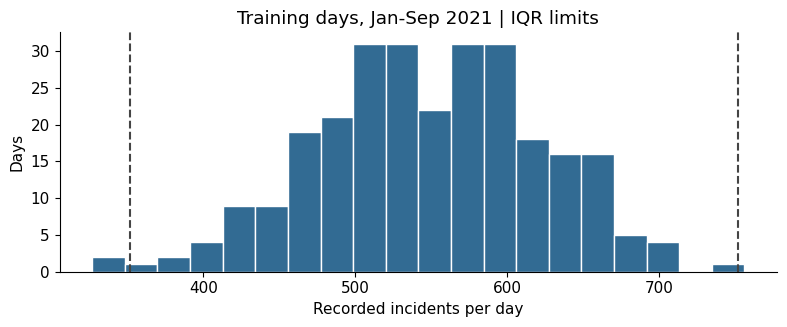

In [11]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 3.4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
fig, ax = plt.subplots()
ax.hist(daily_train, bins=20, color="#326B93", edgecolor="white")
for value in [lower, upper]:
    ax.axvline(value, color="#444444", linestyle="--")
ax.set(xlabel="Recorded incidents per day", ylabel="Days",
       title="Training days, Jan-Sep 2021 | IQR limits")
fig.tight_layout()
plt.show()

<div dir="rtl" align="right">

هیچ روزی به دلیل این قاعده حذف یا بریده نشده است. فراوانی نمودار تعداد روزهاست؛ حجم ثبت روزانه، نرخ جرم به ازای جمعیت نیست.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۶ کدگذاری، تبدیل و هم‌مقیاس‌سازی

شمارهٔ منطقه نام یک دسته است؛ مثلاً منطقهٔ ۴ الزاماً دو برابر منطقهٔ ۲ نیست. برای ساعت نیز دو ویژگی سینوسی و کسینوسی می‌سازیم تا ساعت ۲۳ و صفر نزدیک به هم نمایش داده شوند. تابع زیر این ورودی‌ها را آماده می‌کند. سپس ستون‌های عددی و دسته‌ای را با روش مناسبِ هر گروه تبدیل می‌کنیم.

</div>


In [12]:
def make_features(frame):
    x = frame[["Latitude", "Longitude", "District",
               "Location Description"]].copy()
    x[["Latitude", "Longitude"]] = x[["Latitude", "Longitude"]].astype(float)
    hour = frame["Date"].dt.hour + frame["Date"].dt.minute / 60
    x["HourSin"] = np.sin(2 * np.pi * hour / 24)
    x["HourCos"] = np.cos(2 * np.pi * hour / 24)
    x["Weekday"] = frame["Date"].dt.dayofweek.astype(str)
    return x

X_train, X_test = make_features(train), make_features(test)
num_cols = ["Latitude", "Longitude", "HourSin", "HourCos"]
cat_cols = ["District", "Location Description", "Weekday"]
display(X_train.head(3))

,Latitude,Longitude,District,Location Description,HourSin,HourCos,Weekday
464092,41.877496,-87.760467,15,APARTMENT,0.0,1.0,4
97392,41.670083,-87.641650,5,STREET,0.0,1.0,4
478310,41.713307,-87.645431,22,DRIVEWAY - RESIDENTIAL,0.0,1.0,4


<div dir="rtl" align="right">

One-Hot برای هر دسته یک ستون صفر و یک می‌سازد. اگر دسته‌ای فقط در آزمون ظاهر شود، تنظیم `handle_unknown="ignore"` همهٔ ستون‌های مربوط به همان ویژگی را صفر می‌کند.

`Pipeline` مراحل هر گروه از ستون‌ها را به ترتیب اجرا می‌کند. `ColumnTransformer` نتیجهٔ گروه عددی و گروه دسته‌ای را کنار هم می‌گذارد. پارامترهای این تبدیل‌ها فقط از آموزش به دست می‌آیند.

</div>


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric = Pipeline([("fill", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())])
categorical = Pipeline([
    ("fill", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([
    ("num", numeric, num_cols), ("cat", categorical, cat_cols)])
Z_train = preprocess.fit_transform(X_train)
Z_test = preprocess.transform(X_test)
print("Prepared shapes:", Z_train.shape, Z_test.shape)

Prepared shapes: (149811, 138) (51410, 138)


<div dir="rtl" align="right">

فقط آموزش در تعیین میانه، میانگین، انحراف معیار و دسته‌ها نقش دارد. صفر و یک‌های One-Hot استاندارد نشده‌اند. در نوت‌بوک، تفاوت Dummy و کدگذاری شمارشی را نیز روی ستون District می‌بینیم؛ مقایسه زیر جایگزین مسیر اصلی مدل نیست.

</div>


In [14]:
dummy = OneHotEncoder(drop="first", handle_unknown="ignore")
dummy.fit(X_train[["District"]])
frequency = X_train["District"].value_counts()
count_encoded = X_test["District"].map(frequency).fillna(0)
print("Dummy columns:", len(dummy.get_feature_names_out()))
print("Count encoding, first 3:", count_encoded.head(3).tolist())

Dummy columns: 22
Count encoding, first 3: [7818, 5071, 6659]


<div dir="rtl" align="right">

برای District ترتیب طبیعی نداریم؛ Label/Ordinal Encoding به‌عنوان ورودی مدل فاصله‌ای مناسب این مثال نیست. برای متغیری با ترتیب واقعی، ترتیب باید از معنای داده بیاید.

تبدیل لگاریتمی را روی شمارش مثبت روزانه نشان می‌دهیم، نه شناسه‌ها یا مختصات. Min-Max نیز فقط با حداقل و حداکثر آموزش fit می‌شود. این مثال جدول روزانه را تغییر می‌دهد و به X رکوردی اضافه نمی‌شود.

</div>


In [15]:
from sklearn.preprocessing import MinMaxScaler

log_train = np.log1p(daily_train.to_numpy()).reshape(-1, 1)
log_test = np.log1p(daily_test.to_numpy()).reshape(-1, 1)
minmax = MinMaxScaler().fit(log_train)
scaled_test = minmax.transform(log_test)
print("Train log range:", log_train.min().round(3), log_train.max().round(3))
print("Test scaled range:", scaled_test.min().round(3), scaled_test.max().round(3))

Train log range: 5.793 6.629
Test scaled range: 0.237 0.974


<div dir="rtl" align="right">

مقدار آزمون می‌تواند خارج از بازه صفر تا یک بیفتد؛ این نتیجه وقتی مقدار جدید از کمینه یا بیشینه آموزش فراتر می‌رود، طبیعی است. StandardScaler هم داده را نرمال‌توزیع نمی‌کند و در برابر داده پرت مقاوم نیست. انتخاب تبدیل باید با توزیع و مدل سازگار باشد؛ استفاده هم‌زمان از همه تبدیل‌ها لازم نیست.

</div>


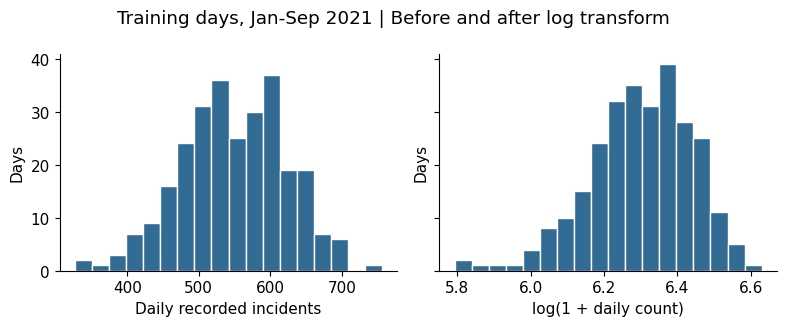

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.3), sharey=True)
for ax, values, label in zip(axes, [daily_train, log_train.ravel()],
                            ["Daily recorded incidents", "log(1 + daily count)"]):
    ax.hist(values, bins=18, color="#326B93", edgecolor="white")
    ax.set(xlabel=label, ylabel="Days")
fig.suptitle("Training days, Jan-Sep 2021 | Before and after log transform")
fig.tight_layout()
plt.show()

<div dir="rtl" align="right">

دو نمودار، اثر فشرده‌سازی مقادیر بزرگ را نشان می‌دهند؛ این تبدیل تضمین نمی‌کند که توزیع نرمال یا عملکرد مدل بهتر شود.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۷ استخراج ویژگی و کاهش ابعاد

PCA چهار ویژگی عددیِ آماده‌شده را به دو ستون جدید، به نام مؤلفه، تبدیل می‌کند. هر مؤلفه ترکیبی خطی از ویژگی‌های اولیه است. استانداردسازی و PCA فقط با آموزش تنظیم می‌شوند و همان تبدیل روی آزمون اجرا می‌شود. انتخاب دو مؤلفه در اینجا آموزشی است.

</div>


In [17]:
from sklearn.decomposition import PCA

N_train = preprocess.named_transformers_["num"].transform(X_train[num_cols])
N_test = preprocess.named_transformers_["num"].transform(X_test[num_cols])
pca = PCA(n_components=2, svd_solver="full")
P_train = pca.fit_transform(N_train)
P_test = pca.transform(N_test)
print("PCA variance:", pca.explained_variance_ratio_.round(3))
print("Total retained:", round(pca.explained_variance_ratio_.sum(), 3))
display(pd.DataFrame(pca.components_, columns=num_cols, index=["PC1", "PC2"]).round(3))

PCA variance: [0.389 0.262]
Total retained: 0.651


,Latitude,Longitude,HourSin,HourCos
PC1,0.707,-0.707,-0.018,-0.012
PC2,-0.007,-0.013,0.708,-0.706


<div dir="rtl" align="right">

جدول بالا ضرایب ترکیب خطی مؤلفه‌هاست، نه خودِ بارهای همبستگی. علامت مثبت یا منفی جهت محور را نشان می‌دهد و بزرگی قدرمطلق برای مقایسه ضرایب مهم است. واریانس حفظ‌شده برابر صحت پیش‌بینی نیست.

LDA برخلاف PCA از برچسب آموزش استفاده می‌کند. با دو کلاس، حداکثر یک محور تفکیکی داریم.

</div>


In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
L_train = lda.fit_transform(N_train, y_train)
L_test = lda.transform(N_test)
print("LDA shapes:", L_train.shape, L_test.shape)

LDA shapes: (149811, 1) (51410, 1)


<div dir="rtl" align="right">

t-SNE فقط برای دیدن همسایگی ۵۰۰ رکورد نمونه‌گیری‌شده از آموزش اجرا می‌شود تا زمان اجرا کوتاه بماند. در scikit-learn، این روش transform برای نگاشت مستقیم آزمون ندارد؛ بنابراین وارد Pipeline نهایی نمی‌شود. فاصله گروه‌های دور و اندازه ظاهری آن‌ها تفسیر قطعی ندارد.

</div>


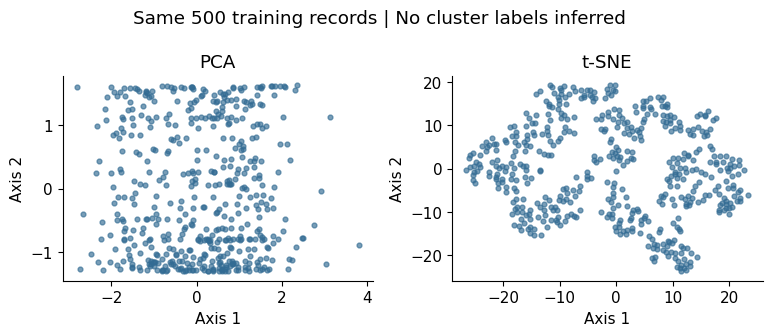

In [19]:
from sklearn.manifold import TSNE

sample_pos = np.random.default_rng(42).choice(len(N_train), 500, replace=False)
T = TSNE(n_components=2, perplexity=30, init="pca",
         learning_rate="auto", random_state=42).fit_transform(N_train[sample_pos])
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
for ax, points, title in zip(axes, [P_train[sample_pos], T], ["PCA", "t-SNE"]):
    ax.scatter(points[:, 0], points[:, 1], s=12, color="#326B93", alpha=0.65)
    ax.set(title=title, xlabel="Axis 1", ylabel="Axis 2")
fig.suptitle("Same 500 training records | No cluster labels inferred")
fig.tight_layout()
plt.show()

<div dir="rtl" align="right">

الگوی بصری به ویژگی‌های انتخاب‌شده و تنظیمات وابسته است؛ جزیره‌های t-SNE به‌تنهایی وجود خوشه واقعی یا امکان تفکیک جرم را اثبات نمی‌کنند. PCA، LDA و t-SNE در اینجا سه مسیر مقایسه‌ای هستند و به‌صورت پیاپی روی هم اجرا نشده‌اند.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۸ انتخاب ویژگی

در PCA ستون‌های تازه ساختیم؛ در انتخاب ویژگی، تعدادی از ستون‌های موجود را نگه می‌داریم. ابتدا ستون‌هایی که در آموزش مقدار ثابت دارند حذف می‌شوند. سپس با امتیاز F، میزان ارتباط هر ویژگی با برچسب آموزش سنجیده و ۱۰ ویژگی انتخاب می‌شود. تعداد ۱۰ آموزشی است؛ تعداد مناسب باید با اعتبارسنجیِ آموزش انتخاب شود.

</div>


In [20]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

nonconstant = VarianceThreshold()
V_train = nonconstant.fit_transform(Z_train)
V_test = nonconstant.transform(Z_test)
selector = SelectKBest(score_func=f_classif, k=10)
S_train = selector.fit_transform(V_train, y_train)
S_test = selector.transform(V_test)
names = preprocess.get_feature_names_out()[nonconstant.get_support()]
selected_names = names[selector.get_support()]
print("Selected shapes:", S_train.shape, S_test.shape)
display(pd.Series(selected_names, name="Selected feature").to_frame())

Selected shapes: (149811, 10) (51410, 10)


,Selected feature
0,num__Latitude
1,cat__District_1
2,cat__District_18
3,cat__District_19
4,cat__Location Description_APARTMENT
5,cat__Location Description_DEPARTMENT STORE
6,cat__Location Description_DRUG STORE
7,cat__Location Description_GROCERY FOOD STORE
8,cat__Location Description_RESIDENCE
9,cat__Location Description_SMALL RETAIL STORE


<div dir="rtl" align="right">

این مثال خانواده فیلتر را عملی می‌کند. روش‌های لفافه‌ای و تعبیه‌شده در متن فصل معرفی شده‌اند؛ طبق همان متن، جزئیات آن‌ها به مطالعه تکمیلی واگذار می‌شود. انتخاب ویژگی و کاهش ابعاد دو انتخاب متفاوت‌اند: اولی ستون‌های موجود را نگه می‌دارد، دومی مؤلفه جدید می‌سازد.

</div>


<div dir="rtl" align="right">

## مثال ۵ـ۹ عدم توازن و زنجیره نهایی
برچسب ۱ یعنی THEFT و برچسب صفر یعنی سایر انواع ثبت‌شده. فراوانی کلاس‌ها و وزن معکوس فراوانی را فقط از آموزش می‌گیریم. وزن بیشتر اقلیت یک ابزار آموزشی است و برتری آن باید ارزیابی شود.

</div>


In [21]:
from sklearn.utils.class_weight import compute_class_weight

counts = y_train.value_counts().sort_index()
weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]),
                               y=y_train.to_numpy())
balance_table = pd.DataFrame({"Train count": counts,
                              "Train percent": 100 * counts / len(y_train),
                              "Class weight": weights})
display(balance_table.round(3))

,Train count,Train percent,Class weight
Primary Type,,,
0,121770,81.282,0.615
1,28041,18.718,2.671


<div dir="rtl" align="right">

برای دیدن تفاوت روش‌های مبتنی بر داده، تعداد نمونه‌های کم‌نمونه‌برداری و بیش‌نمونه‌برداری را هم محاسبه می‌کنیم. این نسخه‌ها صرفاً نمایش آموزشی‌اند و در مدل وزن‌دار آخر استفاده نمی‌شوند؛ آزمون در هیچ‌کدام تغییر نمی‌کند.

</div>


In [22]:
minority = y_train[y_train.eq(1)]
majority = y_train[y_train.eq(0)]
under = pd.concat([minority, majority.sample(len(minority), random_state=42)])
over = pd.concat([majority, minority.sample(len(majority), replace=True, random_state=42)])
display(pd.DataFrame({"Original train": counts,
                      "Undersampled": under.value_counts(),
                      "Oversampled": over.value_counts(),
                      "Untouched test": y_test.value_counts()}).sort_index())

,Original train,Undersampled,Oversampled,Untouched test
Primary Type,,,,
0,121770,28041,121770,40201
1,28041,28041,121770,11209


<div dir="rtl" align="right">

بیش‌نمونه‌برداری بالا رکوردهای اقلیت را تکرار می‌کند و داده جدید واقعی نمی‌سازد. SMOTE/ADASYN درون‌یابی می‌کنند؛ اجرای ساده آن‌ها روی شناسه منطقه و ستون‌های One-Hot ممکن است ترکیب‌های نامعتبر بسازد. برای کوتاه ماندن مثال اصلی، روش وزن‌دهی انتخاب شده است.

اکنون یک Pipeline کامل می‌سازیم تا همان تبدیل‌ها و انتخاب ویژگی هنگام آموزش مدل به‌صورت یک زنجیره اجرا شوند. رگرسیون لجستیک فقط برای کنترل کاربرد خروجی پیش‌پردازش آمده است. مدل با تنظیمات از پیش تعیین‌شده یک بار روی آزمون ارزیابی می‌شود؛ برای تنظیم پارامترها نباید به این نتیجه برگردیم.

</div>


In [23]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = Pipeline([
    ("prepare", clone(preprocess)), ("constant", VarianceThreshold()),
    ("select", SelectKBest(f_classif, k=10)),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))])
model.fit(X_train, y_train)
prediction = model.predict(X_test)
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
rows = []
for name, pred in [("Majority baseline", baseline.predict(X_test)),
                   ("Prepared model", prediction)]:
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred, zero_division=0),
                 "Recall": recall_score(y_test, pred, zero_division=0),
                 "F1": f1_score(y_test, pred, zero_division=0)})
metrics = pd.DataFrame(rows).set_index("Model")
display(metrics.round(3))

,Accuracy,Precision,Recall,F1
Model,,,,
Majority baseline,0.782,0.000,0.000,0.00
Prepared model,0.630,0.314,0.589,0.41


<div dir="rtl" align="right">

Precision، Recall و F1 برای کلاس THEFT گزارش می‌شوند. مدل اکثریت ممکن است صحت ظاهراً زیادی داشته باشد و همه نمونه‌های اقلیت را از دست بدهد. وزن‌دهی هزینه خطاها را عوض می‌کند؛ نتیجه آن تضمین بهبود همه معیارها نیست. آستانه این اجرا همان پیش‌فرض است. افزایش آستانه مثبت معمولاً Recall را کاهش می‌دهد و مثبت کاذب را کم می‌کند؛ تنظیم آستانه باید با اعتبارسنجی آموزش و هزینه هر دو نوع خطا انجام شود.

**مرز استفاده:** این یک تمرین پیش‌پردازش و طبقه‌بندی رکوردهای موجود است. نتیجه، نرخ واقعی جرم، پیش‌بینی وقوع جرم یا مبنای تصمیم درباره افراد نیست. داده جمعیت، مواجهه با خطر و نمونه‌های بدون رخداد در فایل وجود ندارد.

</div>


<div dir="rtl" align="right">

## کنترل و ذخیره خروجی
کنترل زیر مرز آموزش و آزمون، شکل ماتریس‌ها و نبود مقدار نامتناهی در ورودی آماده‌شده را بررسی می‌کند. خروجی‌های CSV و آرایه‌های عددی در پوشه outputs ذخیره می‌شوند تا نتیجه آماده‌سازی قابل استفاده و بازرسی باشد. ستون‌های ماتریس با فایل جدا مشخص‌اند؛ برچسب هدف داخل X قرار نگرفته است.

</div>


In [24]:
from pathlib import Path
from scipy import sparse
import sklearn

assert train["Date"].max() < test["Date"].min()
assert set(train["Case Number"]).isdisjoint(test["Case Number"])
assert Z_train.shape[1] == Z_test.shape[1]
assert np.isfinite(sparse.csr_matrix(Z_train).data).all()
assert np.isfinite(sparse.csr_matrix(Z_test).data).all()
output = Path("outputs")
output.mkdir(exist_ok=True)
sparse.save_npz(output / "X_train_prepared.npz", sparse.csr_matrix(Z_train))
sparse.save_npz(output / "X_test_prepared.npz", sparse.csr_matrix(Z_test))
pd.Series(preprocess.get_feature_names_out(), name="Feature").to_csv(
    output / "Prepared_columns.csv", index=False)
for label, frame, target in [("train", train, y_train), ("test", test, y_test)]:
    pd.DataFrame({"ID": frame["ID"], "Target_THEFT": target}).to_csv(
        output / f"Rows_{label}.csv", index=False)
metrics.to_csv(output / "Model_metrics.csv")
balance_table.to_csv(output / "Class_balance.csv")
pd.Series(selected_names, name="Feature").to_csv(output / "Selected_features.csv", index=False)
print("Checks passed. Saved to:", output)
print("Versions:", pd.__version__, np.__version__, sklearn.__version__)

Checks passed. Saved to: outputs
Versions: 2.3.3 2.3.5 1.7.2


<div dir="rtl" align="right">

## منابع روش‌ها و راهنمای ادامه
مستندات رسمی برای بررسی روش اجرا:
- جلوگیری از نشت و Pipeline: https://scikit-learn.org/stable/common_pitfalls.html
- تبدیل ویژگی‌ها: https://scikit-learn.org/stable/modules/preprocessing.html
- جایگذاری: https://scikit-learn.org/stable/modules/impute.html
- PCA: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- LDA: https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html
- t-SNE: https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

</div>
